Employee Attrition Data Analysis with Python

PROJECT OBJECTIVE 

To analyze employee attrition patterns using exploratory data analysis (EDA) in Python and identify factors associated with employee turnover.

BUSINESS PROBLEMS

Which employee groups show higher attrition?
How does attrition vary by department?
How does attrition vary by job role?
Relationship between attrition and:
-Job satisfaction
-Work-life balance
-Monthly income
-Age
-Experience
-Distribution patterns of key variables
-Comparison between attrition vs non-attrition employees
-Demographic patterns related to attrition
-Work condition factors related to attrition

In [20]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [21]:
emp_df = pd.read_csv("../data/Employee-Attrition.csv")

In [22]:
emp_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [23]:
emp_df.shape

(1470, 35)

In [24]:
emp_df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [25]:
emp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [26]:
emp_df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [27]:
emp_df.duplicated().sum()

0

In [28]:
emp_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [29]:
emp_df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [30]:
cat_cols = emp_df.select_dtypes(include='object').columns
for col in cat_cols:
    emp_df[col] = emp_df[col].astype('category')
    
emp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   category
 2   BusinessTravel            1470 non-null   category
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   category
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   int64   
 7   EducationField            1470 non-null   category
 8   EmployeeCount             1470 non-null   int64   
 9   EmployeeNumber            1470 non-null   int64   
 10  EnvironmentSatisfaction   1470 non-null   int64   
 11  Gender                    1470 non-null   category
 12  HourlyRate                1470 non-null   int64   
 13  JobInvolvement            1470 non-null   int64 

In [31]:
attrition_rate = emp_df["Attrition"].value_counts()['Yes']*100/len(emp_df)
attrition_rate

16.122448979591837

In [32]:
avg_age = emp_df['Age'].mean()
round(avg_age)

37

In [33]:
avg_income = emp_df['MonthlyIncome'].mean()
round(avg_income,2)

6502.93

In [34]:
avg_year_company = emp_df['YearsAtCompany'].mean()
round(avg_year_company)

7

In [35]:
dept_attrition = emp_df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()['Yes']*100
dept_attrition

C:\Users\aditya\AppData\Local\Temp\ipykernel_24504\3507082951.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_attrition = emp_df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()['Yes']*100


Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Yes, dtype: float64

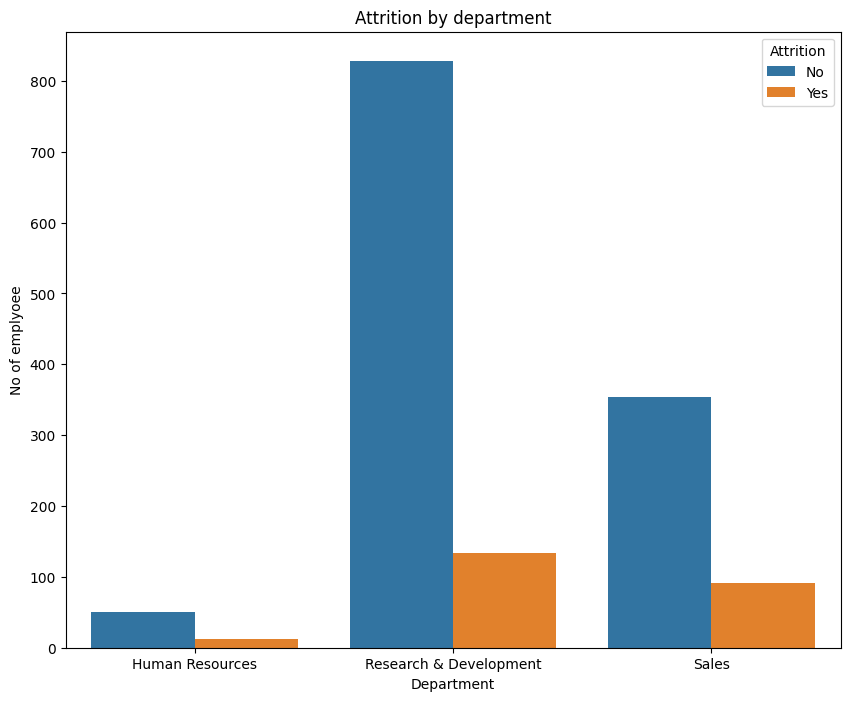

In [36]:
plt.figure(figsize=(10,8))
sns.countplot(data = emp_df, x = 'Department',hue = 'Attrition')
plt.title("Attrition by department")
plt.ylabel("No of emplyoee")
plt.savefig("../output/Attri_depart.png",dpi=500,bbox_inches='tight')
plt.show()

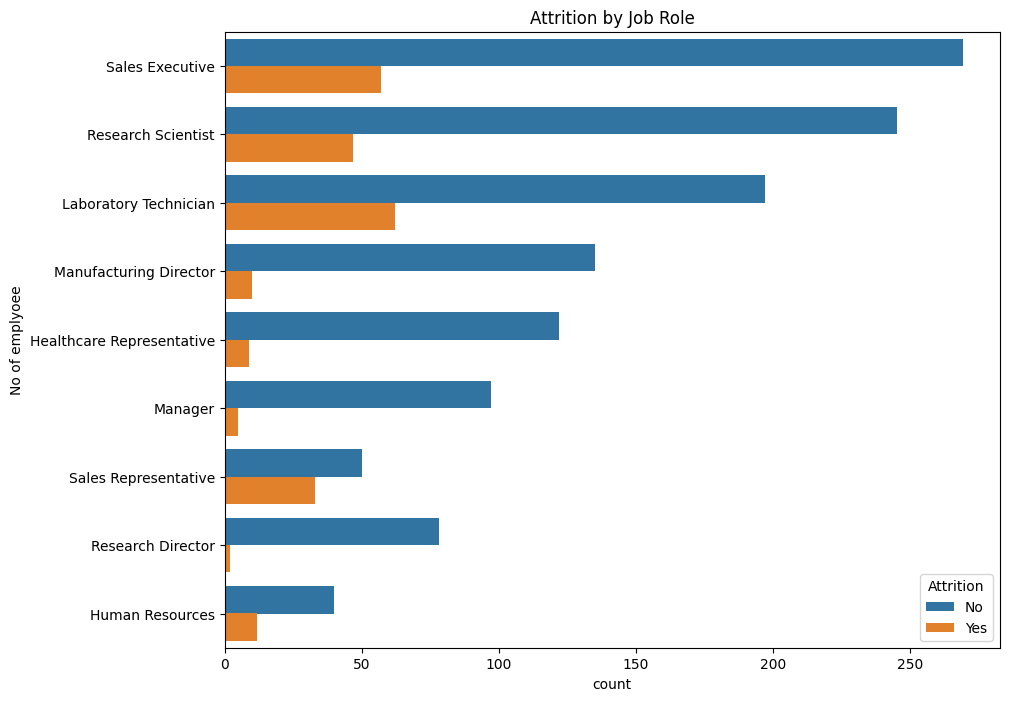

In [37]:
plt.figure(figsize=(10,8))
sns.countplot(data=emp_df, y='JobRole', hue='Attrition', order=emp_df['JobRole'].value_counts().index)
plt.title("Attrition by Job Role")
plt.ylabel("No of emplyoee")
plt.savefig("../output/Attri_JobRole.png",dpi=500,bbox_inches='tight')
plt.show()

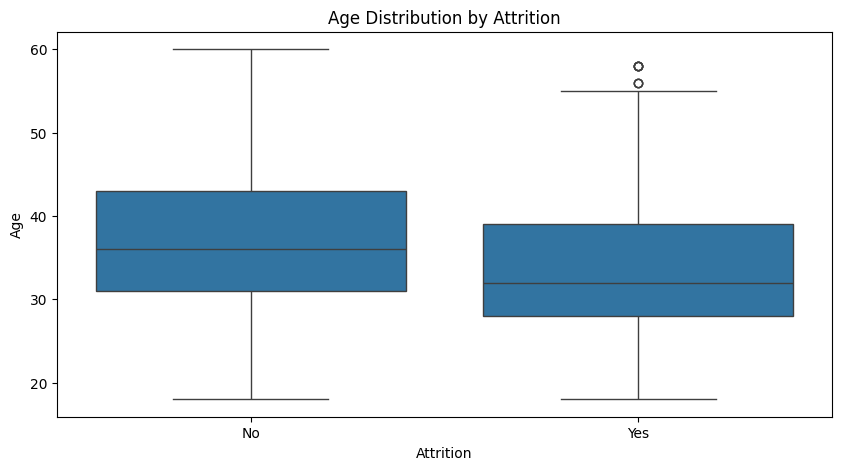

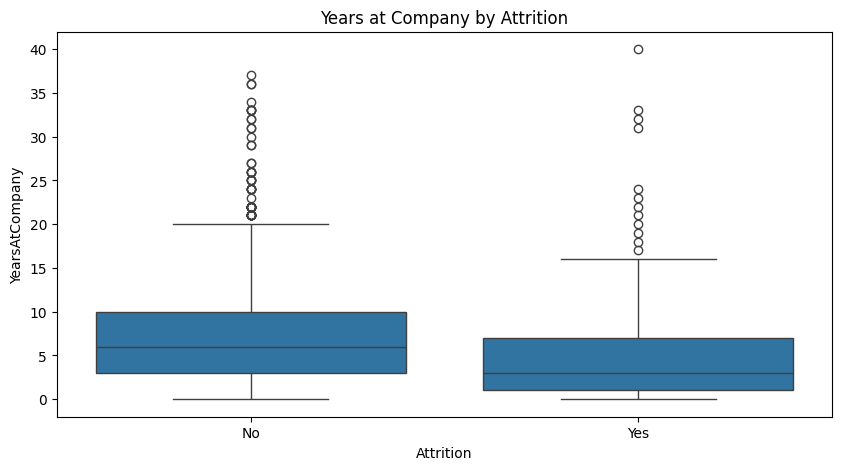

In [38]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Attrition', y='Age', data=emp_df)
plt.title("Age Distribution by Attrition")
plt.savefig("../output/Age_distrib_attrition.png",dpi=500,bbox_inches='tight')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=emp_df)
plt.title("Years at Company by Attrition")
plt.savefig("../output/Years_company_attrition.png",dpi=500,bbox_inches='tight')
plt.show()

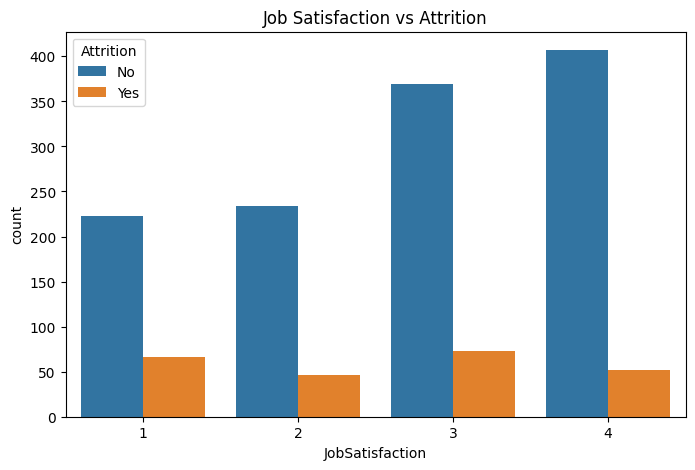

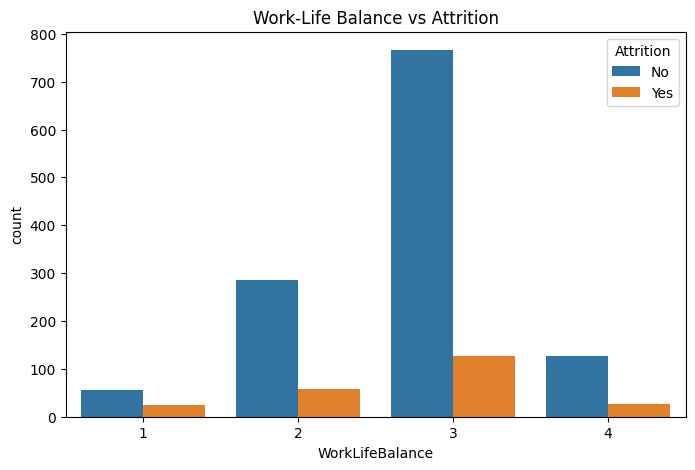

In [39]:
plt.figure(figsize=(8,5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=emp_df)
plt.title("Job Satisfaction vs Attrition")
plt.savefig("../output/job_satisfation_Attrition.png",dpi=500,bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=emp_df)
plt.title("Work-Life Balance vs Attrition")
plt.savefig("../output/work_life_Attrition.png",dpi=500,bbox_inches='tight')

plt.show()

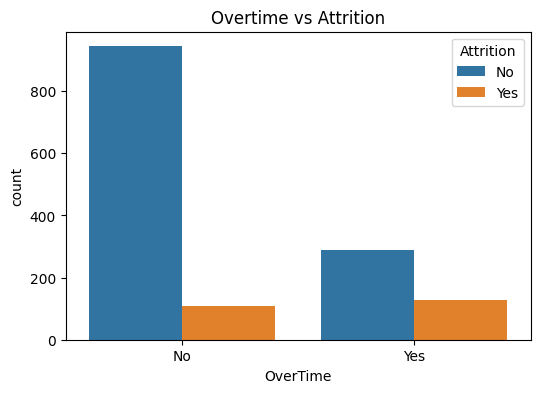

In [40]:
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=emp_df)
plt.title("Overtime vs Attrition")
plt.savefig("../output/Overtime_Attri.png",dpi=500,bbox_inches='tight')
plt.show()

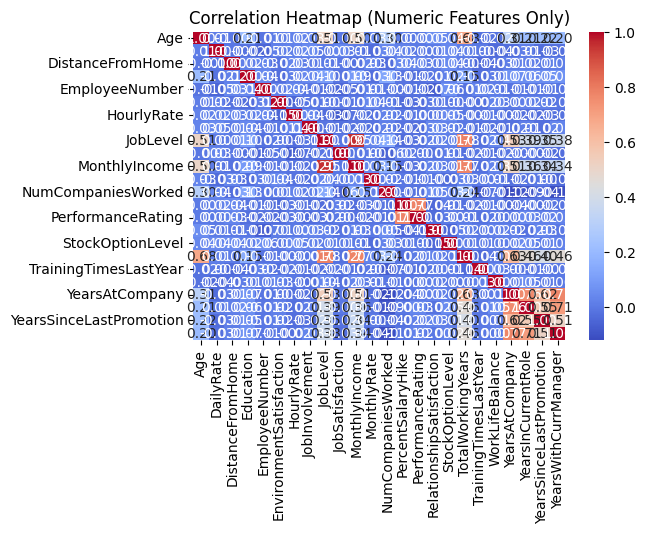

In [41]:
numeric_df = emp_df.select_dtypes(include=['int64', 'float64'])
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1] 
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.savefig("../output/Correlation_map.png",dpi=500,bbox_inches='tight')
plt.show()

Insights

-Attrition is not evenly distributed across departments.

-Certain job roles show higher attrition concentration.

-Employees with lower job satisfaction show higher attrition presence.

-Monthly income shows distribution differences between attrition and non-attrition groups.

-Work-life balance shows variation between attrition groups.

-Younger or less experienced employees show different attrition patterns.

-Attrition patterns are clustered across specific employee segments rather than uniform.


Recommendations

-Prioritize departments with higher attrition concentration for focused workforce review.

-Conduct role-level analysis for job roles consistently showing higher attrition.

-Use job satisfaction patterns to guide workplace improvement discussions.

-Review work-life balance conditions in high-attrition employee groups.

-Use attrition segmentation to structure HR review meetings and reporting.

-Track repeated attrition patterns in specific workforce segments over time.